# Weather Forecasting with Linear Regression -- With Regularization!


**Recitation by Dr. Fangshuo Liao**

In these lab sessions, we will be using Jupyter notebooks running on Google Colab, which has most Python libraries installed.

Please make a copy of the folder in your own Google Drive.

At the end of the recitation, we will be able to handle the implementation of:

1.   Linear regression with polynomial feature expansion.
2.   Regularization in linear regression.
3. Model selection and cross validation.


## Weather prediction

In this recitation, we will use the same weather dataset as last time. You can find the data set in the column-separated file 'NYC_Weather_2016_2022.csv' in the Google Drive folder you had just copied and created.

We will start by allowing our application access to our local Google drives so files can be loaded into our Python programs.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


On the left-side menu in your Google Colab, find the Files symbol to access your Google Drive contents. Under _content/drive/MyDrive_ you will see all of your files and folders. Find the local copy to the the data set _NYC_Weather_2016_2022.csv_ and copy the path by clicking on it on the right three-dot symbol and selecting **_Copy path_**. Inset the path in the read_csv function as string input.

In [2]:
import pandas as pd
import os
import torch

torch.random.manual_seed(41)

data_folder = os.getcwd() + '/drive/MyDrive/' # Your path here

print(os.listdir(data_folder))
df = pd.read_csv(data_folder + 'NYC_Weather_2016_2022.csv').dropna()

# Create a PyTorch Tensor from the DF, same as last time.
datatensor = torch.nn.functional.normalize(
    torch.tensor(df.values[1:,1::].astype(float))
    )

# Split the data into inputs (everything but rain) and labels (rain)
inputs = torch.cat([datatensor[:,0:2], datatensor[:,3::]], dim=1)
labels = datatensor[:,2].unsqueeze(1)

print(inputs.shape, labels.shape)

['Colab Notebooks', 'Copy of Blank Schedule 2023.docx', 'Registration Checklist Summer 2024.gdoc', 'Tutoring Request Form FA21.pdf', 'Untitled document (12).gdoc', 'Untitled document (11).gdoc', 'Steve Yoo_Resume 2024.pdf', 'Accidental Hero.gdoc', 'Conway Text.gdoc', 'Untitled document (10).gdoc', 'Steve Yoo - Math Modeling Research.gdoc', 'Steve Yoo - Math Modeling Research.pdf', 'Copy of CS1114 PTC Mock Exam1 Fall 2024.docx', '시니어 컨설팅   멘토링 마켓 조사.gdoc', 'comp sci midterm exam 1 notes.gdoc', '10 24 Frontend 8.5-8.7.gslides', '시니어즈 시장 조사 script.gdoc', 'Copy of 멋사 와이어프레임.gslides', 'Copy of cs questions 1.gdoc', '제목 없는 스프레드시트.gsheet', 'Steve Yoo_Resume 2024 (1).docx', 'Lab.gdoc', 'Chem Slides', 'Cham.pdf', 'Chem.pdf', '2조 예상 질문 리스트.gdoc', 'Untitled document (9).gdoc', 'Untitled document (8).gdoc', 'Symbols and Abbreviations.xlsx', 'EG Notes.gdoc', ' Four-Trophic-Level Food Web Model .gdraw', 'lab1b - james, kaylyn, steve.rvt',

## Polynomial feature expansion

Somethings a model that is linear in terms of the features may not be sufficient to describe the target. For instance, if the target is quadratic in terms of one of inputs, then any model that is linear in features fails. A standard approach in ML is to add a non-linear feature map:

$$
  \mathbf{x}\in\mathbb{R}^d \rightarrow \phi(\mathbf{x}) \in\mathbb{R}^{d'}
$$

with $d' \geq d$. In this way, our features are more 'expressive'. An example is polynomial feature expansion: for $\mathbf{x} = [x_1, \dots, x_d]$

$$
  \phi(\mathbf{x}) = [1, x_1, \dots, x_d, x_1^2, x_1x_2, \dots, x_{d-1}x_d, x_d^2 ,\dots] \in \mathbb{R}^{1 + d + {d + 1\choose 2} + \dots + {d + k - 1\choose k}}
$$
where $k$ is the degree of the polynomial that you expand to.

In [3]:
from sklearn.preprocessing import PolynomialFeatures

# Simple sklearn built-in function
phi_inputs = torch.tensor(PolynomialFeatures(degree=3).fit_transform(inputs))

# Should be 1 + 8 + 8 * 9 / 2 + 8 * 9 * 10 / 3 / 2 = 165
print(phi_inputs.shape)

torch.Size([59586, 165])


## Defining the Model and Loss -- with Reguarization !!

For transformed inputs $\phi(\mathbf{x})$, our regression model is still linear (in terms of the parameters)

$$
  f(\mathbf{w},\mathbf{x}) = \mathbf{w}^\top\phi(\mathbf{x}) = \sum_{j=1}^dw_i\phi(x)_i
$$

We use the MSE Loss with $\ell_2$-regularization (ridge regression)
$$
  L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^n(f(\mathbf{w},\mathbf{x}_i) - y_i)^2 + \lambda\sum_{j=2}^{d'}w_i^2
$$

In [4]:
from re import L
class LinearRegression(torch.nn.Module):
    def __init__(self, inputSize, outputSize):
        super(LinearRegression, self).__init__()
        # We already included the bias in the term $x^0$. So here we set bias=False.
        self.linear = torch.nn.Linear(inputSize, outputSize, bias=False)

    def forward(self, x):
        y = self.linear(x)
        return y

    def get_w(self):
        return self.linear.weight.squeeze()

class RidgeMSELoss(torch.nn.Module):
    def __init__(self, lmbd: float):
        super().__init__()
        self.lmbd = lmbd
        self.mse = torch.nn.MSELoss() # Same as last time.

    def forward(self, y_pred, y_true, weights):
        mse_loss = self.mse(y_pred, y_true)
        return mse_loss + self.lmbd * (weights.squeeze()[1:] ** 2).sum() # Adding \ell_2 term.

## Separating into training, validation, and test set

We will use 60% of the data for traininig, 20% for validation, and 20% for testing.


In [5]:
# Randomly permute the indices.
n = inputs.shape[0]
perm_n = torch.randperm(n)
train_idxs = perm_n[:int(0.6 * n)]
val_idxs = perm_n[int(0.6 * n):int(0.8 * n)]
test_idxs = perm_n[int(0.8 * n):]

# Obtain train, validation, and test data.
train_in = phi_inputs[train_idxs]
train_out = labels[train_idxs]
val_in = phi_inputs[val_idxs]
val_out = labels[val_idxs]
test_in = phi_inputs[test_idxs]
test_out = labels[test_idxs]

## Feature Standardization

As last time, before we proceed into the training, we need to make sure that the distribution of each feature to be mean 0 and std 1. This will speed up training **a lot**! Here we need to leave-out the first term.

In [6]:
train_in_mean = train_in[:, 1:].mean(axis=0)
train_out_mean = train_out.mean()

train_in_std = train_in[:, 1:].std(axis=0)
train_out_std = train_out.std()

ptrain_in = torch.ones_like(train_in)
ptrain_in[:, 1:] = (train_in[:, 1:] - train_in_mean) / train_in_std
ptrain_out = (train_out - train_out_mean) / train_out_std

## Define the PyTorch Dataset (same as last time.)

In [7]:
from torch.utils.data import Dataset, DataLoader

class WeatherDataset(Dataset):
  def __init__(self, inputs, outputs):
        # Initialize data
        self.n_samples = inputs.shape[0]

        # here the first column is the class label, the rest are the features
        self.x_data = inputs # size [n_samples, n_features]
        self.y_data = outputs # size [n_samples, 1]

  # support indexing such that dataset[i] can be used to get i-th sample
  def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

  # we can call len(dataset) to return the size
  def __len__(self):
      return self.n_samples


trainingData = WeatherDataset(ptrain_in, ptrain_out)

We can now implement the model training and testing in our program. We will define our model with its size parameters for the input and output, and create an iterative loop for optimizing the model parameters using gradient descent:

$$
  \mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla L(\mathbf{w}_t)
$$

Another important parameter is the **learning rate** $\eta$ which determines the scale at which each parameter update will be performed by the optimizer. We run the training for 50 steps.

In [8]:
def train(model, loss, learning_rate, batch_size, num_epochs):
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  loader = DataLoader(dataset=trainingData, batch_size=batch_size, shuffle=False)

  losses = []; step = 0

  for epoch_idx in range(num_epochs):
    for input, target in loader:
      optimizer.zero_grad() # reset gradiant value to zero
      model.double()
      output = model(input) # pass input to model
      err = loss(output, target, model.get_w()) # compute mean squared error between model prediction and target value
      losses.append(err) # store err value to monitor training
      # evaluate the gradient at the end of the computational graph

      err.backward()

      # propagate the evaluated gradient to update model parameters
      optimizer.step()

      print('step {}, loss {}'.format(step, err.item()))

      step += 1
  return model, losses

learning_rate = 0.02
batch_size = len(trainingData)
num_epochs = 30
lmbd = 0.1

model = LinearRegression(inputSize=ptrain_in.shape[1], outputSize=1)
loss = RidgeMSELoss(0.1)

print('Total Iters: ', len(trainingData) // batch_size * num_epochs)
print('Output Scale: ', torch.norm(ptrain_out) ** 2 / len(trainingData))

model, losses = train(model, loss, learning_rate, batch_size, num_epochs)

Total Iters:  30
Output Scale:  tensor(1.0000, dtype=torch.float64)
step 0, loss 0.9405138907631816
step 1, loss 0.43752828440325586
step 2, loss 0.30897928100364613
step 3, loss 0.24357522663554393
step 4, loss 0.20331994472365073
step 5, loss 0.17614506781294675
step 6, loss 0.15686437382129967
step 7, loss 0.14274989341751163
step 8, loss 0.13216508727135137
step 9, loss 0.12405408071631242
step 10, loss 0.11770859766428943
step 11, loss 0.11264263358950954
step 12, loss 0.10851751378699995
step 13, loss 0.10509429465126471
step 14, loss 0.1022024978118154
step 15, loss 0.09971915824479859
step 16, loss 0.0975545963306682
step 17, loss 0.09564265884171017
step 18, loss 0.09393396853467162
step 19, loss 0.0923912186387174
step 20, loss 0.09098586816610085
step 21, loss 0.08969580357478601
step 22, loss 0.08850367149985709
step 23, loss 0.08739568055252059
step 24, loss 0.08636073315874453
step 25, loss 0.08538979118695328
step 26, loss 0.08447540833744054
step 27, loss 0.083611382338

Text(0, 0.5, 'Loss')

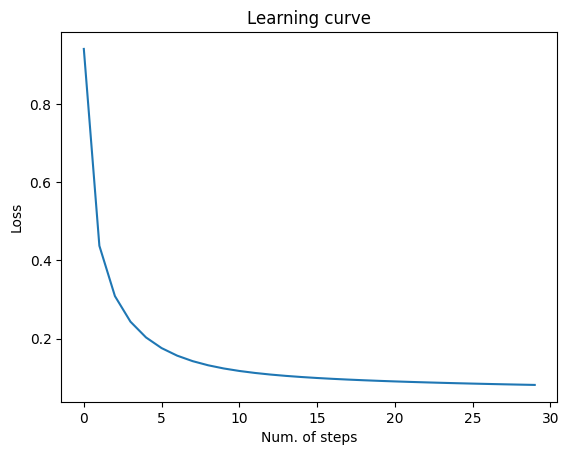

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), torch.stack(losses).detach())
plt.title('Learning curve')
plt.xlabel('Num. of steps')
plt.ylabel('Loss')

When the loss minimization is complete, we can now use the learned model parameters for the actual prediction task. We will use the testing features as input to the model and compare the model output with the actual rain measurements.

tensor(0.0002, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)


Text(0.5, 1.0, 'Linear regression model performance in New York City rain prediction')

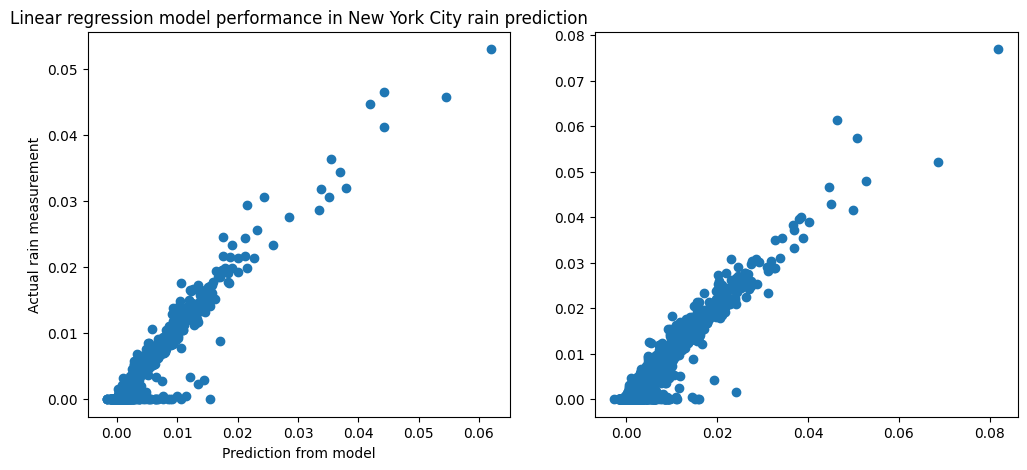

In [10]:
with torch.no_grad(): # this signal informs torch that further operations will not need the gradient computation
  ## Remember to process the input for the test!!!

  ptest_in = torch.ones_like(test_in)
  ptest_in[:, 1:] = (test_in[:, 1:] - train_in_mean) / train_in_std
  raw_test_pred = model(ptest_in)
  raw_train_pred = model(ptrain_in)

  ## Remember to scale the outputs back!!!
  test_pred = raw_test_pred * train_out_std + train_out_mean
  train_pred = raw_train_pred * train_out_std + train_out_mean

plt.figure(figsize=(12, 5))

ax1 = plt.subplot(121)
ax1.scatter(test_pred, test_out)

print(torch.mean(torch.abs(test_pred - test_out)))

ax2 = plt.subplot(122)
ax2.scatter(train_pred, train_out)

print(torch.mean(torch.abs(train_pred - train_out)))


ax1.set_xlabel('Prediction from model')
ax1.set_ylabel('Actual rain measurement')
ax1.set_title('Linear regression model performance in New York City rain prediction')

## Using Validation Set to Select $\lambda$

Now we are going to use the validation set to select the model trained with the best regularization parameter $\lambda$. For simplicity, we will not be using GD-based training. Instead, we will adopt the normalize equation, which is faster:

$$
  \mathbf{w}^\star = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}
$$

What we do here is to try a bunch of $\lambda$ values, evaluate the validation loss for each value's resulting model, and apply the model to the test set. We will define some helper functions to make the task easier.

In [11]:
def compute_w_star(inputs, labels, lmbd):
  reg_term = lmbd * torch.eye(inputs.shape[1])
  reg_term[0,0] = 0
  return torch.linalg.inv(inputs.T @ inputs + reg_term) @ (inputs.T @ labels)


def eval_loss(inputs, labels, w_star, train_in_mean, train_in_std,
              train_out_mean, train_out_std):
  inputs_scaled = torch.ones_like(inputs)
  inputs_scaled[:, 1:] = (inputs[:, 1:] - train_in_mean) / train_in_std
  preds = inputs_scaled @ w_star
  preds_scaled = preds * train_out_std + train_out_mean
  return torch.norm(preds_scaled.squeeze() - labels.squeeze()) ** 2 / inputs.shape[0] / torch.norm(labels) ** 2

**For Demonstration Purpose**, we are using only a subset of the training data. In addition, we add some noise to the data.

In [12]:
# Take a subset of training data, and add noise.
subset_size = 100
ptrain_in_subset = ptrain_in[:subset_size] + 0.1 * torch.randn((subset_size, ptrain_in.shape[1]))
ptrain_out_subset = ptrain_out[:subset_size]
train_out_subset = train_out[:subset_size]

# A range of lambdas.
lmbd_vals = 10 ** (torch.arange(11) / 5 - 1)
print('Lambda values: ', lmbd_vals)

train_losses = []
val_losses = []
for lmbd in lmbd_vals:
  w_star = compute_w_star(ptrain_in_subset, ptrain_out_subset, lmbd)
  ptrain_pred_subset = ptrain_in_subset @ w_star * train_out_std + train_out_mean
  train_losses.append(torch.norm(ptrain_pred_subset - train_out_subset) ** 2 / subset_size / torch.norm(train_out_subset) ** 2)
  val_losses.append(eval_loss(val_in, val_out, w_star, train_in_mean,
                              train_in_std, train_out_mean, train_out_std))

Lambda values:  tensor([ 0.1000,  0.1585,  0.2512,  0.3981,  0.6310,  1.0000,  1.5849,  2.5119,
         3.9811,  6.3096, 10.0000])


## Plot $\lambda$ v.s. loss

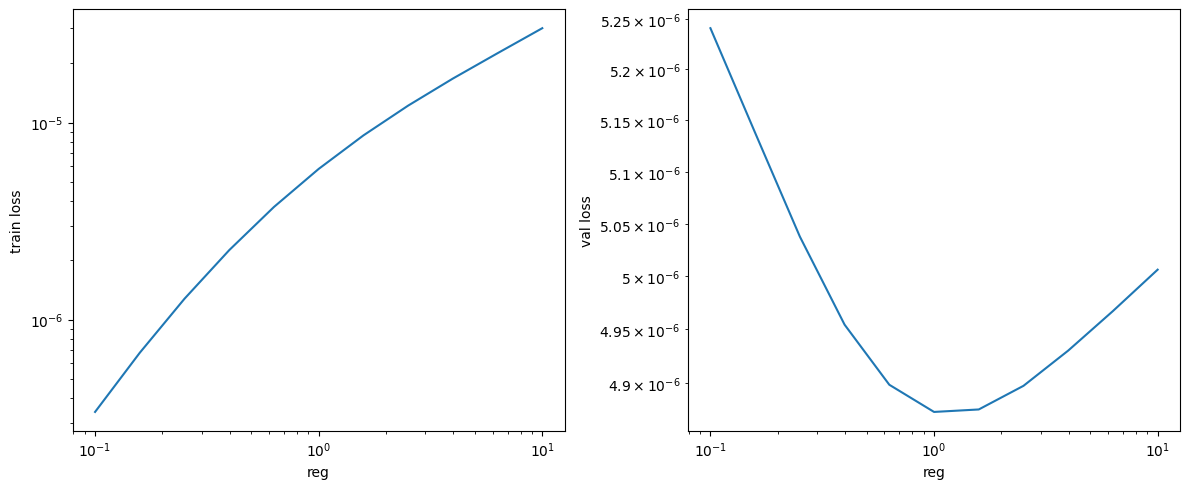

In [13]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot the training loss v.s. lambda
axs[0].plot(lmbd_vals, train_losses)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('reg')
axs[0].set_ylabel('train loss')

# Plot the validation loss v.s. lambda
axs[1].plot(lmbd_vals, val_losses)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('reg')
axs[1].set_ylabel('val loss')

plt.tight_layout()
plt.show()

## Exercise 1

Implement a LASSO regression (or $\ell_1$-regularized linear regression), where the loss is:

$$
  L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^n(f(\mathbf{w},\mathbf{x}_i) - y_i)^2 + \lambda\sum_{j=2}^{d'}|w_i|
$$

Train the model using GD and compare the sparsity of the $\mathbf{w}^\star$ to $\ell_2$-regularized regression. We are going to use a heavy regularization $\lambda = 1$ to see the difference.

**sparsity**: the number of zeros in a vector.

step 0, loss 1.1932089207246008
step 1, loss 1.157787479668821
step 2, loss 1.1244768846255422
step 3, loss 1.0931267675933793
step 4, loss 1.063598632056162
step 5, loss 1.0357648558340267
step 6, loss 1.009507780633745
step 7, loss 0.9847188806215952
step 8, loss 0.9612980030281676
step 9, loss 0.9391526744189469
step 10, loss 0.9181974668329353
step 11, loss 0.8983534185089652
step 12, loss 0.8795475043903374
step 13, loss 0.861712152027136
step 14, loss 0.8447847988858666
step 15, loss 0.8287074874313447
step 16, loss 0.8134264946692291
step 17, loss 0.7988919931320511
step 18, loss 0.7850577405597098
step 19, loss 0.7718807957694842
step 20, loss 0.7593212584328725
step 21, loss 0.7473420306789389
step 22, loss 0.7359085986281124
step 23, loss 0.7249888321281903
step 24, loss 0.7145528011170981
step 25, loss 0.7045726071761278
step 26, loss 0.6950222289641081
step 27, loss 0.6858773803383988
step 28, loss 0.6771153800737362
step 29, loss 0.6687150321857318
step 0, loss 8.404989821

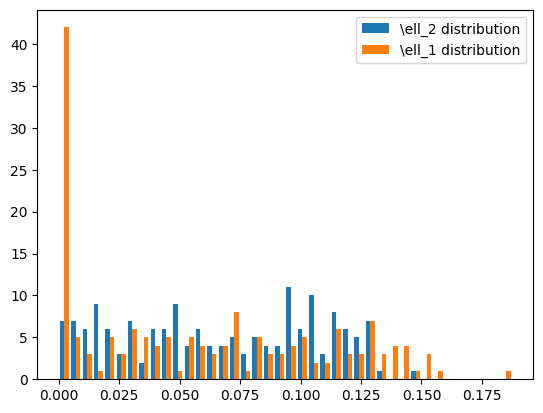

In [15]:
X = ptrain_in
y = ptrain_out

learning_rate = 0.0005
batch_size = len(trainingData)
num_epochs = 30
lmbd = 1

model_l2 = LinearRegression(inputSize=X.shape[1], outputSize=1)
ridge_loss = RidgeMSELoss(lmbd)
model_l2, _ = train(model_l2, ridge_loss, learning_rate, batch_size, num_epochs)

model_l1 = LinearRegression(inputSize=X.shape[1], outputSize=1)

## Your code here. To start, you need to implement a loss similar to the ridge loss.
class LassoMSELoss(torch.nn.Module):
  def __init__(self, imbd: float):
    super().__init__()
    self.lmbd = lmbd
    self.mse = torch.nn.MSELoss()

  def forward(self, y_pred, y_true, weights):
      mse_loss = self.mse(y_pred, y_true)
      return mse_loss + self.lmbd * torch.abs(weights.squeeze()[1:]).sum()  # ℓ1 term

lasso_loss = LassoMSELoss(lmbd)
## You can directly call the train function several blocks above to train the model.
model_l1, _ = train(model_l1, lasso_loss, learning_rate, batch_size, num_epochs)

## Change the code below. You can obtain the parameter by model.get_w()

w_l2 = model_l2.get_w()
w_l1 = model_l1.get_w()

# Normalize for better comparison.
w_l2 = w_l2 / torch.norm(w_l2)
w_l1 = w_l1 / torch.norm(w_l1)

# Plot the magnitude histogram.
plt.hist([torch.abs(w_l2).detach().numpy(), torch.abs(w_l1).detach().numpy()],
         bins=40, label=['\\ell_2 distribution', '\\ell_1 distribution'])
plt.legend()

## Exercise 2

Suppose you are only give 100 data. Implement a 10-fold cross-validation strategy to select the best $\ell_2$ regularization parameter $\lambda$.

In [20]:
# You can only use the noisy subset below.
subset_size = 100
ptrain_in_subset = ptrain_in[:subset_size] + 0.1 * torch.randn((subset_size, ptrain_in.shape[1]))
ptrain_out_subset = ptrain_out[:subset_size]

k_folds = 10
lmbd_vals = 10 ** (torch.arange(11) / 5 - 1)


## Your code goes here
mse_metric = torch.nn.MSELoss()

def train_fold(train_in, train_out, lmbd, learning_rate=0.01, num_epochs=200):
    model = LinearRegression(inputSize=train_in.shape[1], outputSize=1)
    model.double()
    loss_fn = RidgeMSELoss(lmbd)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        output = model(train_in)
        err = loss_fn(output, train_out, model.get_w())
        err.backward()
        optimizer.step()
    return model

n = ptrain_in_subset.shape[0]
fold_size = n // k_folds
perm = torch.randperm(n)

cv_scores = []
for lmbd in lmbd_vals:
    fold_losses = []
    for k in range(k_folds):
        val_idx = perm[k * fold_size : (k + 1) * fold_size]
        train_idx = torch.cat([perm[:k * fold_size], perm[(k + 1) * fold_size:]])

        Xtr, ytr = ptrain_in_subset[train_idx], ptrain_out_subset[train_idx]
        Xval, yval = ptrain_in_subset[val_idx], ptrain_out_subset[val_idx]

        model = train_fold(Xtr, ytr, lmbd.item())
        with torch.no_grad():
            pred = model(Xval)
            fold_losses.append(mse_metric(pred, yval).item())

    avg_mse = sum(fold_losses) / len(fold_losses)
    cv_scores.append(avg_mse)
    print(f"lambda = {lmbd.item():.4f}  ->  avg CV MSE = {avg_mse:.4f}")

best_idx = int(torch.argmin(torch.tensor(cv_scores)))
best_lambda = lmbd_vals[best_idx].item()
print(f"Best lambda selected by 10-fold CV: {best_lambda:.4f}")

lambda = 0.1000  ->  avg CV MSE = 0.0246
lambda = 0.1585  ->  avg CV MSE = 0.0099
lambda = 0.2512  ->  avg CV MSE = 0.0089
lambda = 0.3981  ->  avg CV MSE = 0.0096
lambda = 0.6310  ->  avg CV MSE = 0.0135
lambda = 1.0000  ->  avg CV MSE = 0.0200
lambda = 1.5849  ->  avg CV MSE = 0.0327
lambda = 2.5119  ->  avg CV MSE = 0.0535
lambda = 3.9811  ->  avg CV MSE = 0.0820
lambda = 6.3096  ->  avg CV MSE = 0.1176
lambda = 10.0000  ->  avg CV MSE = 0.1560
Best lambda selected by 10-fold CV: 0.2512
